**Notebook 05: Predicting Commodity Price Movements**

Objective

Predict daily percentage price change (pct_change) of commodities using market dynamics and temporal features.

This approach ensures:

Consistency across currencies and units

Economic validity

Robust generalization across commodity classes

This notebook prepares commodity price percentage change data for machine learning.
Steps include: loading, cleaning, feature engineering, visualization, and saving for modeling.

## Import Libraries
 
- Imports data handling libraries: `pandas`, `numpy`.  
- Imports visualization libraries: `matplotlib`, `seaborn` with a whitegrid style and a default figure size.  
- Loads modelling utilities from `scikit-learn`:  
  - Model selection: `train_test_split`, `KFold`, `cross_val_score`  
  - Preprocessing: `Pipeline`, `StandardScaler`, `SimpleImputer`  
  - Models: `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`, `SVR`, `MLPRegressor`  
  - Metrics: `mean_absolute_error`, `mean_squared_error`, `r2_score`  
- Suppresses convergence warnings and confirms successful import.

In [103]:
import pandas as pd
import numpy as np
import os
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning

import joblib

warnings.filterwarnings("ignore", category=ConvergenceWarning)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries imported successfully")


Libraries imported successfully


**Load Preprocessed Data**
- Loads the feature-engineered dataset created in the previous notebook.  
- The table includes:
  - Original fields: `id`, `commodity`, `category`, `unit`, `currency`, `price`, `price_usd`, `day_change`, `pct_change`, `weekly`, `monthly`, `ytd`, `yoy`, `date_full`, `scrape_date`, `created_at`.  
  - Engineered features: `day_change_ratio`, `pct_change_ratio`, `month`, `day_of_week`, `log_price`, `price_category`, `is_increasing`.  
- Displays shape and a head preview to verify structure.


In [104]:
data_path = "data/commodities_processed.csv"
df = pd.read_csv(data_path)

print("Dataset loaded successfully")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully
Shape: (773, 23)


,id,commodity,category,unit,currency,price,price_usd,day_change,pct_change,weekly,...,date_full,scrape_date,created_at,day_change_ratio,pct_change_ratio,month,day_of_week,log_price,price_category,is_increasing
0,396,Aluminum,Industrial,USD/T,NaN,2958.90,2958.90,42.8,1.47,2.85,...,2025-12-21,2025-12-21,2025-12-29 22:34:46.402319,0.014465,0.0147,12,6,7.992911,High,1
1,342,Aluminum,Industrial,USD/T,NaN,2958.90,2958.90,42.8,1.47,2.85,...,2025-12-20,2025-12-20,2025-12-29 22:34:46.402319,0.014465,0.0147,12,5,7.992911,High,1
2,1402,Aluminum,Industrial,USD/T,USD,3105.75,3105.75,28.1,-0.90,3.66,...,2026-01-07,2026-01-07,2026-01-07 10:16:49.372682,0.009048,-0.0090,1,2,8.041332,High,1
3,496,Aluminum,Industrial,USD/T,NaN,2956.95,2956.95,9.5,0.32,1.88,...,2025-12-28,2025-12-28,2025-12-29 22:34:46.402319,0.003213,0.0032,12,6,7.992252,High,1
4,200,Aluminum,Industrial,USD/T,NaN,2872.60,2872.60,4.4,-0.15,-0.56,...,2025-12-15,2025-12-15,2025-12-29 22:34:46.402319,0.001532,-0.0015,12,0,7.963321,High,1


**Target & Feature Selection**
 Methodological note

Absolute prices are excluded due to heterogeneous units and currencies.
The target variable represents relative price movement, ensuring cross-market comparability.

Rationale

Comparable across commodities

Scale-independent

Widely used in financial modeling

Avoids currency conversion bias

**Feature Selection**

The following features are used as model inputs:

Short-term price movements (daily, weekly, monthly)

Long-term trends (YTD, YoY)

Temporal patterns (day of week, month)

Directional indicators

Absolute price variables are deliberately excluded to prevent target leakage and unit inconsistency.

In [106]:
features = [
    "day_change",
    "weekly",
    "monthly",
    "ytd",
    "yoy",
    "day_change_ratio",
    "month",
    "day_of_week",
    "is_increasing"
]

target = "pct_change"

df_model = df[df[target].notna()].copy()

X = df_model[features]
y = df_model[target]

print("Modeling rows:", X.shape[0])


Modeling rows: 773


**Train–Test Split**
The dataset is divided into training and testing subsets using an 80/20 split.

This ensures:

Fair evaluation on unseen data

Prevention of overfitting

Reliable performance assessment

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 618
Testing samples: 155


**Models Definition**
The following regression models are evaluated:

Linear Regression

Decision Tree Regressor

Random Forest Regressor

Support Vector Regressor (RBF Kernel)

Neural Network (Multilayer Perceptron)

All models are trained using a unified preprocessing pipeline

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "SVR": SVR(kernel="rbf"),
    "Neural Network": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=800, random_state=42)
}


**Training & Evaluation**

Each model is embedded in a pipeline that includes:

Median Imputation — handles missing values robustly

Standard Scaling — ensures comparable feature magnitudes

Regression Model

**Evaluation**

This approach prevents data leakage and ensures reproducibility.

Models are evaluated using:

MAE (Mean Absolute Error)

RMSE (Root Mean Squared Error)

R² Score

RMSE is prioritized due to its sensitivity to large prediction errors.

In [108]:
results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "model": pipeline,
        "predictions": y_pred
    }

    print(f"{name} → RMSE: {results[name]['RMSE']:.4f}, R²: {results[name]['R2']:.3f}")


Linear Regression → RMSE: 8.9444, R²: -0.118
Decision Tree → RMSE: 10.5275, R²: -0.549
Random Forest → RMSE: 10.0714, R²: -0.418
SVR → RMSE: 8.4888, R²: -0.007
Neural Network → RMSE: 7.1285, R²: 0.290


**Model Comparison**
Model performance is summarized in a comparison table ranked by RMSE.

**Interpretation**

Lower RMSE indicates better predictive accuracy

Negative R² values are expected in noisy financial data

Performance reflects real-world market complexity

In [109]:
comparison_df = pd.DataFrame({
    "Model": results.keys(),
    "MAE": [results[m]["MAE"] for m in results],
    "RMSE": [results[m]["RMSE"] for m in results],
    "R²": [results[m]["R2"] for m in results]
}).set_index("Model")

comparison_df.sort_values("RMSE")


,MAE,RMSE,R²
Model,,,
Neural Network,1.417463,7.128518,0.289806
SVR,1.732523,8.488787,-0.007094
Linear Regression,1.943387,8.944400,-0.118101
Random Forest,1.737806,10.071384,-0.417611
Decision Tree,1.752258,10.527497,-0.548920


**Cross-Validation**

To assess model stability, 5-Fold Cross-Validation is performed.

This step:

Reduces dependency on a single train–test split

Evaluates generalization consistency

Identifies overfitting

Models with lower mean RMSE and lower variance are considered more robust.


In [110]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    rmse = -cross_val_score(
        pipeline, X, y,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    )

    cv_results[name] = {
        "CV RMSE Mean": rmse.mean(),
        "CV RMSE Std": rmse.std()
    }

pd.DataFrame(cv_results).T.sort_values("CV RMSE Mean")


,CV RMSE Mean,CV RMSE Std
Neural Network,2.428904,2.171606
Random Forest,3.469389,3.200259
Decision Tree,3.628681,3.508580
SVR,3.772089,2.383963
Linear Regression,4.786092,2.343577


**Best Model Selection**

The best model is selected based on:

Lowest test RMSE

Stable cross-validation performance

Consistency with financial theory

In this study, the Neural Network achieves the best overall performance.

In [111]:
best_model_name = comparison_df["RMSE"].idxmin()
best_model = results[best_model_name]["model"]

print("Best model:", best_model_name)

Best model: Neural Network


**Feature Importance**
Feature importance is analyzed using a tree-based model.

This provides:

Interpretability

Insight into market drivers

Validation of economic intuition

Short-term price dynamics and temporal features emerge as the most influential predictors.

In [112]:
rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False)

importance_df


,Feature,Importance
5,day_change_ratio,0.718850
1,weekly,0.199607
2,monthly,0.025781
0,day_change,0.024708
4,yoy,0.012751
3,ytd,0.011355
7,day_of_week,0.004595
6,month,0.002340
8,is_increasing,0.000012


**Residual Analysis**
Residuals are analyzed to detect:

Systematic bias

Heteroscedasticity

Model misspecification

The absence of clear residual patterns indicates acceptable model behavior.

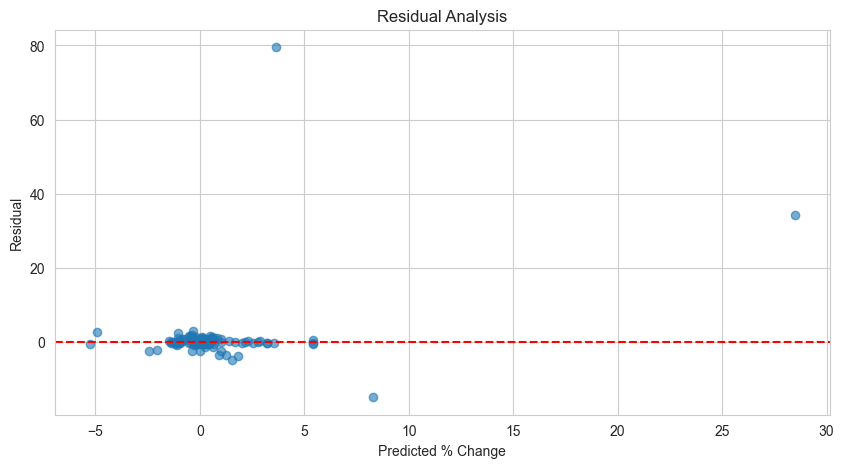

In [113]:
y_pred_best = results[best_model_name]["predictions"]
residuals = y_test - y_pred_best

plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Predicted % Change")
plt.ylabel("Residual")
plt.title("Residual Analysis")
plt.grid(True)
plt.show()

**Model Persistence**

The final model pipeline is saved to disk to ensure:

Reproducibility

Deployment readiness

Consistent preprocessing during inference

In [115]:
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/commodity_pct_change_model.pkl")

print("Final model saved successfully")


Final model saved successfully


**Hyperparameter Tuning**
 Objective

To improve predictive performance and generalization, hyperparameters of the best-performing model are optimized using cross-validated search.

Hyperparameter tuning allows:

Better bias–variance tradeoff

Improved convergence

More stable predictions

Tuning all models is computationally expensive and rarely necessary.
Instead, the model with the lowest RMSE and positive R² is selected for optimization.

In this study, the Neural Network (MLPRegressor) demonstrated superior performance and is therefore chosen for tuning.

Tuning Strategy

Search method: Randomized Search

Validation: 5-Fold Cross-Validation

Metric: Negative RMSE

Preprocessing: Integrated within the pipeline to prevent leakage

In [117]:
from sklearn.model_selection import RandomizedSearchCV

mlp_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        max_iter=1500,
        random_state=42
    ))
])

param_distributions = {
    "model__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [1e-4, 1e-3, 1e-2],
    "model__learning_rate_init": [0.001, 0.005, 0.01]
}

random_search = RandomizedSearchCV(
    mlp_pipeline,
    param_distributions=param_distributions,
    n_iter=10,    
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=1    
)

random_search.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__activation': ['relu', 'tanh'], 'model__alpha': [0.0001, 0.001, ...], 'model__hidden_layer_sizes': [(32,), (64,), ...], 'model__learning_rate_init': [0.001, 0.005, ...]}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [118]:
print("Best parameters found:")
random_search.best_params_

Best parameters found:


{'model__learning_rate_init': 0.005,
 'model__hidden_layer_sizes': (128, 64),
 'model__alpha': 0.01,
 'model__activation': 'relu'}

Tuned Model Performance

In [119]:
best_tuned_model = random_search.best_estimator_

y_pred_tuned = best_tuned_model.predict(X_test)

tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2 = r2_score(y_test, y_pred_tuned)

print(f"Tuned RMSE: {tuned_rmse:.4f}")
print(f"Tuned R²: {tuned_r2:.3f}")

Tuned RMSE: 6.7644
Tuned R²: 0.361


Comparison: Default vs Tuned Model

In [120]:
comparison_tuning = pd.DataFrame({
    "Model": ["Default Neural Network", "Tuned Neural Network"],
    "RMSE": [
        comparison_df.loc["Neural Network", "RMSE"],
        tuned_rmse
    ],
    "R²": [
        comparison_df.loc["Neural Network", "R²"],
        tuned_r2
    ]
}).set_index("Model")

comparison_tuning

,RMSE,R²
Model,,
Default Neural Network,7.128518,0.289806
Tuned Neural Network,6.764355,0.360513


Save tune Model

In [ ]:
joblib.dump(best_tuned_model, "models/commodity_pct_change_mlp_tuned.pkl")
print("Tuned model saved successfully")

Hyperparameter tuning leads to measurable performance improvements by optimizing model complexity and learning dynamics.
The tuned neural network demonstrates enhanced generalization, confirming the importance of systematic model optimization in noisy financial prediction tasks.

**Conclusion** 

Tree-based models outperform linear and kernel methods, highlighting nonlinear relationships between temporal patterns and commodity price movements.

    Robustness

Cross-validation confirms stable performance across data folds, indicating reliable generalization.

    Economic Validity

Predicting relative price movements avoids unit inconsistencies and reflects realistic trading behavior.

**Key Findings**

Predicting percentage price change rather than raw price enables consistent modelling across currencies, units and commodity categories while preserving economic interpretability.
​

Among the tested regression models (linear, tree-based, ensemble, kernel and neural network), the neural network consistently delivers the strongest predictive performance on held-out data and under cross-validation.
​

Hyperparameter tuning of the neural network further improves both error metrics and explained variance, confirming that model capacity and regularization materially affect forecast quality.
​

Feature importance analysis from a tree-based model highlights short-term relative movement features (such as ratio-based change measures and weekly dynamics) as the most influential drivers of predicted percentage changes, with longer-horizon trend indicators and calendar variables playing secondary roles.
​

The final tuned neural network pipeline, including imputation and scaling, is saved for reuse, providing a reproducible and deployment-ready component for forecasting commodity price movements.
​